# 🎬 From Concepts to Clustering: Building a Movie Recommender

**Notebook developed by** SzuLun Huang <szuh@berkeley.edu>  
**Under the guidance of** Eric Van Dusen <ericvd@berkeley.edu>  
**UC Berkeley, Data Science**

---

### 📌 Compatibility
This notebook runs on **JupyterHub** and **Google Colab**.

> **Before You Begin:**
> - Run cells **in order** from top to bottom
> - No external packages beyond `pandas`, `numpy`, and `ipywidgets` (already available)
> - **Core activity: ~30 minutes** (concepts, matching game, and the recommender itself)
> - **Optional extensions (Part 5 comparison + written justification) can run longer** —
>   plan for up to 45 minutes total if including those

---

**What you'll do:**
1. Learn how AI, ML, DL, and LLMs relate to each other — and pick up the vocabulary you'll
   need (with a matching game, not flashcards)
2. Build a real movie recommender using a similarity-based technique related to **Clustering**
   (Unsupervised Learning)
3. Test what stuck, using what you actually built


In [1]:
#@title 📦 Import libraries (run once)
import pandas as pd
import numpy as np
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output
import random
_rnd = random
from sklearn.cluster import KMeans

print("✅ Libraries loaded (pandas, numpy, ipywidgets, sklearn).")


✅ Libraries loaded (pandas, numpy, ipywidgets, sklearn).


## 🧭 Part 1: Where Does This All Fit?

Ever open a streaming app, see **"Recommended for you,"** and wonder how it decides what to show?

Before we build a tiny version ourselves, let's place today's ideas on the ML map.

**Today's storyline:**  
**AI → ML → Supervised vs. Unsupervised → Features → Feature Vectors → Similarity → K-Means**

The goal is not to memorize every ML method. It's to understand one important idea well enough to build with it.


### 🗺️ Where do traditional models and LLMs actually sit?

<svg width="100%" viewBox="0 0 680 400" role="img">
<title>Where traditional models and LLMs sit in the ML hierarchy</title>
<desc>AI contains ML; ML splits into traditional models (Decision Tree, Linear/Logistic Regression, K-Means, K-NN, SVM) and DL (deep learning), where LLM is one DL model applied to language, alongside CNN and diffusion models for other data types.</desc>
<defs>
<marker id="arrow" viewBox="0 0 10 10" refX="8" refY="5" markerWidth="6" markerHeight="6" orient="auto-start-reverse"><path d="M2 1L8 5L2 9" fill="none" stroke="context-stroke" stroke-width="1.5" stroke-linecap="round" stroke-linejoin="round"/></marker>
</defs>
<g fill="#E6F1FB" stroke="#185FA5">
<rect x="30" y="30" width="620" height="340" rx="20" stroke-width="0.5"/>
<text x="50" y="58" font-size="14" font-weight="500" fill="#0C447C">AI</text>
</g>
<g fill="#E1F5EE" stroke="#0F6E56">
<rect x="55" y="80" width="570" height="270" rx="16" stroke-width="0.5"/>
<text x="75" y="105" font-size="14" font-weight="500" fill="#085041">ML — learns from data instead of hand-written rules</text>
</g>
<g fill="#F1EFE8" stroke="#5F5E5A">
<rect x="80" y="130" width="255" height="180" rx="12" stroke-width="0.5"/>
</g>
<text x="207" y="152" text-anchor="middle" font-size="14" font-weight="500" fill="#2C2C2A">Traditional models</text>
<text x="207" y="172" text-anchor="middle" font-size="12" fill="#5F5E5A">No neural network layers</text>
<text x="207" y="200" text-anchor="middle" font-size="12" fill="#5F5E5A">Decision Tree</text>
<text x="207" y="222" text-anchor="middle" font-size="12" fill="#5F5E5A">Linear / Logistic Regression</text>
<text x="207" y="244" text-anchor="middle" font-size="12" fill="#5F5E5A">K-Means</text>
<text x="207" y="266" text-anchor="middle" font-size="12" fill="#5F5E5A">K-Nearest Neighbors</text>
<text x="207" y="288" text-anchor="middle" font-size="12" fill="#5F5E5A">SVM</text>
<g fill="#FAEEDA" stroke="#854F0B">
<rect x="365" y="130" width="235" height="180" rx="12" stroke-width="0.5"/>
</g>
<text x="482" y="152" text-anchor="middle" font-size="14" font-weight="500" fill="#412402">DL — deep learning</text>
<text x="482" y="172" text-anchor="middle" font-size="12" fill="#854F0B">Layered neural networks</text>
<g fill="#FAECE7" stroke="#993C1D">
<rect x="390" y="200" width="185" height="70" rx="10" stroke-width="1"/>
</g>
<text x="482" y="225" text-anchor="middle" font-size="14" font-weight="500" fill="#4A1B0C">LLM</text>
<text x="482" y="245" text-anchor="middle" font-size="12" fill="#712B13">DL applied to language</text>
<text x="482" y="290" text-anchor="middle" font-size="12" fill="#854F0B">also: CNN (images),</text>
<text x="482" y="305" text-anchor="middle" font-size="12" fill="#854F0B">diffusion models (image gen)</text>
</svg>

**The takeaway:** LLM is just *one* Deep Learning model, applied specifically to language. It's not the only DL model (CNNs handle images, diffusion models generate images) — and it's definitely not the whole of AI. Traditional models like Decision Tree, Linear/Logistic Regression, K-Means, and K-NN don't use neural network layers at all, but they're still very much ML.

### ✅❌ Quick true/false check

**1. Is Decision Tree a form of Deep Learning?**
> **No.** It's a traditional ML model — it splits data using tree-shaped branching rules, with no neural network layers involved.

**2. Is LLM the only kind of Deep Learning model?**
> **No.** CNNs handle images, diffusion models generate images — LLM is just the DL model specialized for language.

**3. Does K-Means need labeled data to work?**
> **No.** It's unsupervised — it finds groupings from the data's structure alone, no human-provided labels required.


## 🎓 Two Ways ML Learns: Supervised vs. Unsupervised

**Supervised learning** — you give the system labeled examples ("this email is spam,"
"this one isn't"), and it learns to predict labels for new, unseen data. Think of the AI
Writing Assistant: humans set up examples of good outputs, and the system learns from that
guidance.

**Unsupervised learning** — nobody provides labels. The system just looks at the data and
finds structure on its own — grouping similar things together without being told what
"similar" means in advance. **This is what our Movie Recommender does today**: nobody
labeled which movies "go together" — the system figures it out from the features alone.
This specific technique is called **Clustering**.

### 📏 A tricky question: how do you know if it worked?

For supervised learning, this is fairly direct — you can check if predictions match the
known correct labels (accuracy, precision, recall).

**For unsupervised learning, there's no answer key to check against.** How do you know if
a clustering result is "good"? Usually by asking: are items *within* a group actually
similar to each other, and are different groups actually different? There's no single
correct clustering — which is exactly what you'll run into in Part 3, when you have to
justify *why* one set of movie recommendations feels better than another, with no fixed
right answer to fall back on.

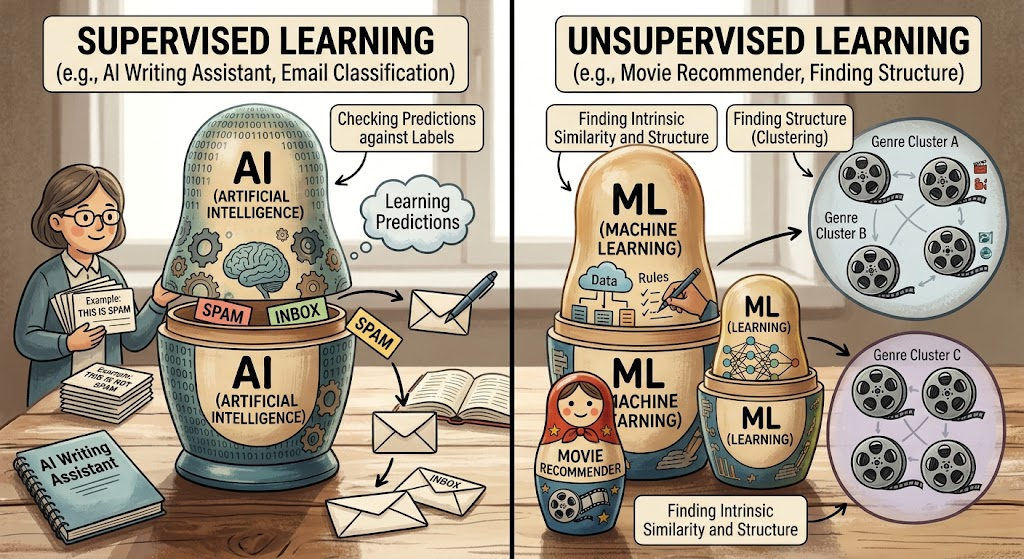

## Part 1b: Algorithm, Training, and Model — Untangling the Confusing Words

If you've ever heard **"train a model"** and thought *wait, what does that actually mean?* — you're not alone.

- **Algorithm** — a procedure for solving a problem.
- **Training** — the process of using data to adjust what the algorithm has learned.
- **Model** — the learned result that can then be used on new data.

Keep one question in mind for the movie recommender:

> **Did the computer learn something from data, or did we simply apply a formula?**

That distinction becomes important when we compare **cosine similarity** with **K-Means** later.


## 📋 The Seven Steps of a Machine Learning Project

Beyond the vocabulary, ML projects tend to follow the same basic sequence every time. See if
you can put these seven steps in the right order — drag each row up or down, then check your
answer.

1. **Gathering data** — collecting the raw data you'll learn from
2. **Preparing that data** — cleaning duplicates, fixing errors, visualizing it
3. **Choosing a model** — picking an algorithm suited to the problem
4. **Training** — the algorithm learns patterns from the data (often the slowest step)
5. **Evaluation** — testing on data the model never saw during training
6. **Hyperparameter tuning** — adjusting settings to improve results
7. **Prediction** — using the trained model on brand-new data

In [2]:
#@title Seven steps: drag to reorder
from IPython.display import display, HTML
import random as _rnd

_uid = str(_rnd.randint(10000, 99999))

steps_game_html = f"""
<div id="list{_uid}" style="display:flex;flex-direction:column;gap:8px;max-width:520px;font-family:sans-serif"></div>
<div style="margin-top:1rem;display:flex;gap:8px;align-items:center">
  <button id="checkBtn{_uid}" style="padding:8px 16px;border-radius:8px;border:1px solid #ccc;background:#fff;cursor:pointer">
    Check order
  </button>
  <span id="result{_uid}" style="font-size:13px"></span>
</div>
<script>
(function() {{
  const UID = "{_uid}";
  const correct = [
    "Gathering data",
    "Preparing that data",
    "Choosing a model",
    "Training",
    "Evaluation",
    "Hyperparameter tuning",
    "Prediction"
  ];
  let items = [...correct].sort(() => Math.random() - 0.5);
  let dragIndex = null;

  function renderSteps() {{
    const list = document.getElementById("list" + UID);
    if (!list) return;
    list.innerHTML = "";
    items.forEach((text, i) => {{
      const row = document.createElement("div");
      row.draggable = true;
      row.dataset.index = i;
      row.style.cssText = "display:flex;align-items:center;gap:10px;padding:10px 14px;background:#f5f5f5;border:1px solid #ddd;border-radius:8px;cursor:grab";
      row.innerHTML = '<span style="color:#999">::</span><span style="font-size:14px;color:#222">' + text + '</span>';
      row.addEventListener("dragstart", e => {{
        dragIndex = i;
        e.dataTransfer.effectAllowed = "move";
      }});
      row.addEventListener("dragover", e => e.preventDefault());
      row.addEventListener("drop", e => {{
        e.preventDefault();
        const dropIndex = Number(row.dataset.index);
        const moved = items.splice(dragIndex, 1)[0];
        items.splice(dropIndex, 0, moved);
        const resultEl = document.getElementById("result" + UID);
        if (resultEl) resultEl.textContent = "";
        renderSteps();
      }});
      list.appendChild(row);
    }});
  }}

  function checkOrder() {{
    const resultEl = document.getElementById("result" + UID);
    if (!resultEl) return;
    const allCorrect = items.every((text, i) => text === correct[i]);
    if (allCorrect) {{
      resultEl.style.color = "green";
      resultEl.textContent = "All seven in the right order!";
    }} else {{
      const numCorrect = items.filter((text, i) => text === correct[i]).length;
      resultEl.style.color = "#c0392b";
      resultEl.textContent = numCorrect + " of 7 in the right position. Keep adjusting.";
    }}
  }}

  const btn = document.getElementById("checkBtn" + UID);
  if (btn) btn.onclick = checkOrder;

  renderSteps();
}})();
</script>
"""

display(HTML(steps_game_html))

## 🎯 A Few More Terms You'll Hear Constantly

**Target / Label** — the answer the model is trying to predict. In a spam filter, the label
is "spam" or "not spam." In our Movie Recommender, there technically isn't one — that's part
of why it's unsupervised.

**Prediction** — what the trained model outputs when you give it new data it hasn't seen
before. Feed the model a new movie's features, and its prediction is which cluster (or which
similar movies) it belongs with.

**Overfitting** — the model memorized quirks and noise in the training data instead of
learning the real pattern. It looks great on data it's already seen, but performs badly on
anything new. (Imagine memorizing the answers to one specific practice test instead of
actually learning the material — you'd ace that test and fail a real exam.)

**Underfitting** — the opposite problem: the model is too simple to capture the real pattern
at all, so it performs poorly even on the data it trained on.

---
### 🔍 Optional Detour: The Bias-Variance Tradeoff

*This is a deeper dive into overfitting/underfitting. It is not required for building the Movie Recommender.*

If you want the intuition behind why a model can be **too simple** or **too complex**, explore the interactive demo below.

> **Main path:** You can skip this and continue to the Matching Game.


In [3]:
#@title Bias-variance tradeoff: interactive demo

bias_variance_html = """
<div style="font-family:sans-serif;max-width:680px">

<div style="display:flex;gap:8px;align-items:center;margin-bottom:0.75rem">
  <label style="font-size:14px;color:#666">Model complexity</label>
  <input type="range" id="complexity" min="1" max="15" value="1" step="1"
         style="flex:1" oninput="bvUpdate(this.value)">
  <span id="complexityOut" style="font-size:14px;font-weight:600;min-width:20px">1</span>
</div>

<p id="stateLabel" style="font-size:14px;font-weight:600;margin:0 0 0.75rem;color:#c0392b">
  Underfitting — too simple to capture the pattern
</p>

<!-- Top: data + fitted curve -->
<svg id="fitSvg" width="100%" viewBox="0 0 640 200" style="display:block;margin-bottom:1rem"></svg>

<!-- Bottom: train / test error curves (pure SVG, no Chart.js) -->
<div style="position:relative">
  <svg id="errSvg" width="100%" viewBox="0 0 640 220" style="display:block"></svg>
</div>

<div style="display:flex;gap:16px;margin-top:8px;font-size:12px;color:#666">
  <span style="display:flex;align-items:center;gap:4px">
    <span style="width:10px;height:10px;border-radius:2px;background:#2a78d6"></span>Training error
  </span>
  <span style="display:flex;align-items:center;gap:4px">
    <span style="width:10px;height:10px;border-radius:2px;background:#e34948"></span>Test error
  </span>
  <span style="display:flex;align-items:center;gap:4px">
    <span style="width:10px;height:2px;background:#0ca30c"></span>Sweet spot
  </span>
</div>

<script>
(function() {
  // ----- data points for the top scatter -----
  const points = [
    {x:40,y:150},{x:90,y:110},{x:140,y:130},{x:190,y:80},{x:240,y:100},
    {x:290,y:60},{x:340,y:90},{x:390,y:70},{x:440,y:110},{x:490,y:85},
    {x:540,y:120},{x:590,y:95}
  ];

  function kernelFit(bandwidth) {
    const out = [];
    for (let x = 30; x <= 610; x += 6) {
      let wsum = 0, ysum = 0;
      points.forEach(p => {
        const w = Math.exp(-((p.x - x) ** 2) / (2 * bandwidth * bandwidth));
        wsum += w; ysum += w * p.y;
      });
      out.push({x, y: ysum / wsum});
    }
    return out;
  }

  function drawFit(complexity) {
    const bandwidth = 260 / complexity;
    const curve = kernelFit(bandwidth);
    const path = 'M ' + curve.map(p => p.x + ',' + p.y).join(' L ');
    const circles = points.map(p =>
      '<circle cx="' + p.x + '" cy="' + p.y + '" r="4" fill="#999"/>'
    ).join('');
    document.getElementById('fitSvg').innerHTML =
      '<path d="' + path + '" fill="none" stroke="#2a78d6" stroke-width="2.5"/>' + circles;
  }

  // ----- bottom error chart (pure SVG) -----
  // layout
  const W = 640, H = 220;
  const pad = {l: 48, r: 20, t: 16, b: 40};
  const plotW = W - pad.l - pad.r;
  const plotH = H - pad.t - pad.b;

  const complexities = Array.from({length: 15}, (_, i) => i + 1);
  const trainErr = complexities.map(c => 30 * Math.exp(-c / 4) + 2);
  const testErr  = complexities.map(c => 8 + Math.pow(c - 5, 2) * 0.9);
  const yMax = Math.max(...trainErr, ...testErr) * 1.1;

  function xScale(c) { return pad.l + ((c - 1) / 14) * plotW; }
  function yScale(v) { return pad.t + plotH - (v / yMax) * plotH; }

  function pathFrom(vals) {
    return vals.map((v, i) => {
      const x = xScale(complexities[i]);
      const y = yScale(v);
      return (i === 0 ? 'M ' : 'L ') + x + ',' + y;
    }).join(' ');
  }

  function drawErrChart(activeC) {
    const trainPath = pathFrom(trainErr);
    const testPath  = pathFrom(testErr);
    const sweetX = xScale(5);

    // grid lines
    let grid = '';
    for (let i = 0; i <= 4; i++) {
      const y = pad.t + (i / 4) * plotH;
      grid += '<line x1="' + pad.l + '" y1="' + y + '" x2="' + (W - pad.r) +
              '" y2="' + y + '" stroke="#e1e0d9" stroke-width="1"/>';
    }

    // axes labels
    const xLabel = '<text x="' + (pad.l + plotW / 2) + '" y="' + (H - 8) +
                   '" text-anchor="middle" font-size="12" fill="#555">Model complexity</text>';
    const yLabel = '<text x="14" y="' + (pad.t + plotH / 2) +
                   '" text-anchor="middle" font-size="12" fill="#555" ' +
                   'transform="rotate(-90,14,' + (pad.t + plotH / 2) + ')">Error</text>';

    // complexity tick labels
    let ticks = '';
    [1, 5, 10, 15].forEach(c => {
      const x = xScale(c);
      ticks += '<text x="' + x + '" y="' + (H - 24) +
               '" text-anchor="middle" font-size="11" fill="#666">' + c + '</text>';
    });

    // sweet-spot vertical line
    const sweet = '<line x1="' + sweetX + '" y1="' + pad.t + '" x2="' + sweetX +
                  '" y2="' + (pad.t + plotH) + '" stroke="#0ca30c" stroke-width="2" stroke-dasharray="4 3"/>';

    // active complexity marker
    const ax = xScale(activeC);
    const marker = '<line x1="' + ax + '" y1="' + pad.t + '" x2="' + ax +
                   '" y2="' + (pad.t + plotH) + '" stroke="#888" stroke-width="1.5"/>';

    document.getElementById('errSvg').innerHTML =
      grid +
      '<path d="' + trainPath + '" fill="none" stroke="#2a78d6" stroke-width="2.5"/>' +
      '<path d="' + testPath  + '" fill="none" stroke="#e34948" stroke-width="2.5"/>' +
      sweet + marker + xLabel + yLabel + ticks;
  }

  // ----- slider handler -----
  window.bvUpdate = function(val) {
    const c = Number(val);
    document.getElementById('complexityOut').textContent = c;
    drawFit(c);
    drawErrChart(c);

    const label = document.getElementById('stateLabel');
    if (c <= 3) {
      label.textContent = 'Underfitting — too simple to capture the pattern';
      label.style.color = '#c0392b';
    } else if (c <= 8) {
      label.textContent = 'Good fit — close to the sweet spot';
      label.style.color = '#27ae60';
    } else {
      label.textContent = 'Overfitting — chasing noise in the data';
      label.style.color = '#c0392b';
    }
  };

  // initial draw
  drawFit(1);
  drawErrChart(1);
})();
</script>
</div>
"""

display(HTML(bias_variance_html))

**What you're seeing:** at low complexity, the curve can't bend enough to follow the data —
that's underfitting, and both training and test error are high. At high complexity, the
curve chases every point exactly, including random noise — that's overfitting: training
error keeps dropping, but test error rises because the model learned noise that won't repeat
on new data. The sweet spot is where test error is lowest — not where training error is
lowest.

---
### 🔍 Optional Detour: Reinforcement Learning

*Our Movie Recommender uses Unsupervised Learning, not Reinforcement Learning.*

This section rounds out the ML picture by showing a third major learning setup:

> **Agent → Action → Reward → Learn**

If you're following the main movie-recommender path, you can safely skip this section.


In [4]:
#@title Reinforcement learning: mouse maze animation

_uid = str(_rnd.randint(10000, 99999))  # unique per run → no id collision

maze_html = f"""
<div id="mazeRoot{_uid}" style="font-family:sans-serif;max-width:780px;margin:0 auto">

<button id="startMazeBtn{_uid}" style="
  display:block;margin:0 auto 14px;padding:10px 22px;
  border-radius:10px;border:1px solid #38bdf8;background:#0d1420;
  color:#38bdf8;font-size:14px;cursor:pointer;font-family:sans-serif">
  ▶ Start Maze Animation
</button>

<div style="display:flex;gap:14px;flex-wrap:wrap;justify-content:center;align-items:flex-start">
  <div style="text-align:center">
    <p style="font-size:12px;color:#666;margin:0 0 6px">Attempt 1<br><span style="font-size:10px">Mostly exploring</span></p>
    <div id="grid1{_uid}" style="display:grid;grid-template-columns:repeat(5,36px);grid-template-rows:repeat(5,36px);gap:2px"></div>
  </div>
  <div style="text-align:center">
    <p style="font-size:12px;color:#666;margin:0 0 6px">Attempt 5<br><span style="font-size:10px">Finding useful paths</span></p>
    <div id="grid5{_uid}" style="display:grid;grid-template-columns:repeat(5,36px);grid-template-rows:repeat(5,36px);gap:2px"></div>
  </div>
  <div style="text-align:center">
    <p style="font-size:12px;color:#666;margin:0 0 6px">Attempt 10<br><span style="font-size:10px">Learning improves</span></p>
    <div id="grid10{_uid}" style="display:grid;grid-template-columns:repeat(5,36px);grid-template-rows:repeat(5,36px);gap:2px"></div>
  </div>
  <div style="text-align:center">
    <p style="font-size:12px;color:#666;margin:0 0 6px">Attempt 20<br><span style="font-size:10px">Mostly knows the way</span></p>
    <div id="grid20{_uid}" style="display:grid;grid-template-columns:repeat(5,36px);grid-template-rows:repeat(5,36px);gap:2px"></div>
  </div>
  <div style="text-align:center">
    <p style="font-size:12px;color:#666;margin:0 0 6px">Attempt 30<br><span style="font-size:10px">Much more confident</span></p>
    <div id="grid30{_uid}" style="display:grid;grid-template-columns:repeat(5,36px);grid-template-rows:repeat(5,36px);gap:2px"></div>
  </div>
</div>

<p id="status{_uid}" style="text-align:center;font-size:13px;color:#666;margin:12px 0 0">
Click the button above to watch the mouse learn...
</p>

<div style="max-width:720px;margin:12px auto 0;padding:12px 16px;border:1px solid #ddd;
            border-radius:10px;background:#fafafa;font-size:12px;line-height:1.5;color:#555">
  <strong>What is happening?</strong>
  The mouse starts without knowing the best path.
  Each attempt gives feedback: <strong>reward</strong> for the goal,
  <strong>penalty</strong> for a trap, small cost per step.
  Over attempts the Q-values update and the mouse improves.
</div>

<script>
(function() {{
  const UID = "{_uid}";
  const SIZE = 5;
  const goal = {{r:4, c:4}};
  const traps = [{{r:1,c:2}}, {{r:3,c:1}}];
  const isTrap = (r,c) => traps.some(t => t.r === r && t.c === c);
  const isGoal = (r,c) => r === goal.r && c === goal.c;
  const key = (r,c) => r + '_' + c;

  let Q = {{}};
  function resetQ() {{
    Q = {{}};
    for (let r = 0; r < SIZE; r++)
      for (let c = 0; c < SIZE; c++)
        Q[key(r,c)] = {{up:0, down:0, left:0, right:0}};
  }}
  resetQ();

  function drawGrid(elId, mousePos, path) {{
    const grid = document.getElementById(elId);
    if (!grid) return;
    grid.innerHTML = '';
    for (let r = 0; r < SIZE; r++) {{
      for (let c = 0; c < SIZE; c++) {{
        const cell = document.createElement('div');
        cell.style.cssText = 'width:36px;height:36px;border-radius:4px;display:flex;align-items:center;justify-content:center;font-size:16px;';
        if (isGoal(r,c)) {{
          cell.style.background = '#bbf7d0';
          cell.textContent = '🧀';
        }} else if (isTrap(r,c)) {{
          cell.style.background = '#fecaca';
          cell.textContent = '💀';
        }} else if (path && path.some(p => p.r === r && p.c === c)) {{
          cell.style.background = '#dbeafe';
        }} else {{
          cell.style.background = '#f1f5f9';
        }}
        if (mousePos && mousePos.r === r && mousePos.c === c) {{
          cell.textContent = '🐭';
          cell.style.background = '#fef08a';
        }}
        grid.appendChild(cell);
      }}
    }}
  }}

  // initial empty grids
  ['grid1','grid5','grid10','grid20','grid30'].forEach(id =>
    drawGrid(id + UID, null, null)
  );

  function chooseAction(r, c, eps) {{
    const actions = ['up','down','left','right'];
    if (Math.random() < eps) return actions[Math.floor(Math.random() * 4)];
    const qs = Q[key(r,c)];
    let best = actions[0], bestQ = qs[best];
    for (const a of actions) if (qs[a] > bestQ) {{ bestQ = qs[a]; best = a; }}
    return best;
  }}

  function step(r, c, action) {{
    let nr = r, nc = c;
    if (action === 'up')    nr = Math.max(0, r - 1);
    if (action === 'down')  nr = Math.min(SIZE - 1, r + 1);
    if (action === 'left')  nc = Math.max(0, c - 1);
    if (action === 'right') nc = Math.min(SIZE - 1, c + 1);
    return {{r: nr, c: nc}};
  }}

  function runEpisode(eps) {{
    let r = 0, c = 0;
    const trail = [{{r, c}}];
    let steps = 0;
    while (!isGoal(r, c) && steps < 50) {{
      const a = chooseAction(r, c, eps);
      const next = step(r, c, a);
      let reward = -0.05;
      if (isTrap(next.r, next.c)) reward = -1;
      if (isGoal(next.r, next.c)) reward = 1;
      const oldQ = Q[key(r,c)][a];
      const nextMax = Math.max(...Object.values(Q[key(next.r, next.c)]));
      Q[key(r,c)][a] = oldQ + 0.4 * (reward + 0.9 * nextMax - oldQ);
      r = next.r; c = next.c;
      trail.push({{r, c}});
      steps++;
    }}
    return trail;
  }}

  function sleep(ms) {{ return new Promise(res => setTimeout(res, ms)); }}

  async function playTrail(elId, trail, delay) {{
    for (let i = 0; i < trail.length; i++) {{
      drawGrid(elId, trail[i], trail.slice(0, i + 1));
      await sleep(delay);
    }}
  }}

  async function runMaze() {{
    const btn = document.getElementById('startMazeBtn' + UID);
    const status = document.getElementById('status' + UID);
    if (!btn || !status) return;

    btn.disabled = true;
    btn.textContent = 'Running...';
    resetQ();

    let trail1, trail5, trail10, trail20, trail30;
    for (let ep = 1; ep <= 30; ep++) {{
      const eps = Math.max(0.05, 1 - ep / 25);
      const trail = runEpisode(eps);
      if (ep === 1)  trail1  = trail;
      if (ep === 5)  trail5  = trail;
      if (ep === 10) trail10 = trail;
      if (ep === 20) trail20 = trail;
      if (ep === 30) trail30 = trail;
    }}

    status.textContent = 'Attempt 1: mostly exploring...';
    await playTrail('grid1' + UID, trail1, 160);

    status.textContent = 'Attempt 5: finding useful paths...';
    await playTrail('grid5' + UID, trail5, 120);

    status.textContent = 'Attempt 10: learning improves...';
    await playTrail('grid10' + UID, trail10, 100);

    status.textContent = 'Attempt 20: mostly knows the way...';
    await playTrail('grid20' + UID, trail20, 80);

    status.textContent = 'Attempt 30: much more confident...';
    await playTrail('grid30' + UID, trail30, 60);

    status.textContent = 'Notice the progression: explore → feedback → update → improve.';
    btn.disabled = false;
    btn.textContent = '▶ Replay Animation';
  }}

  // Safe bind after DOM is in the page
  const btn = document.getElementById('startMazeBtn' + UID);
  if (btn) {{
    btn.onclick = runMaze;
  }}
}})();
</script>
</div>
"""

display(HTML(maze_html))

**Key vocabulary:** the mouse is the **agent**, the maze is the **environment**, its
position is the **state**, moving up/down/left/right is an **action**, and the cheese or
trap is the **reward** or **punishment**. Nobody labeled the correct path in advance —
the agent discovered it purely through trial and error.

## 🧩 Part 2: Match the Term to Its Definition

Before we build anything, let's lock in the vocabulary you'll use in the next few minutes.

Every term below appears again later. When you match a card, don't just ask **"Is this definition correct?"** Also ask:

> **"Where will I see this idea in the Movie Recommender?"**

That connection is the important part.


In [5]:
#@title Matching game setup

pairs = [
    ("AI", "The broadest category — any technique that makes a machine behave intelligently."),
    ("ML", "A subset of AI where the system learns patterns from data instead of following hand-written rules."),
    ("DL", "A subset of ML using layered neural networks, good for messy data like images or text."),
    ("LLM", "A deep learning model trained specifically to process and generate human language."),
    ("Algorithm", "A fixed, reusable set of steps for finding patterns in data — the recipe, not the finished dish."),
    ("Model", "The specific result you get after training an algorithm on your own data."),
    ("Training", "The process of running an algorithm on real data so it learns patterns from it."),
    ("K-Means", "A clustering algorithm that groups data into a chosen number of clusters."),
]

# Build shuffled card deck: each pair becomes two cards (term card + definition card)
cards = []
for i, (term, definition) in enumerate(pairs):
    cards.append({"pair_id": i, "text": term, "kind": "term"})
    cards.append({"pair_id": i, "text": definition, "kind": "def"})
_rnd.shuffle(cards)

print(f"Deck ready: {len(cards)} cards ({len(pairs)} pairs). Run the next cell to play.")

Deck ready: 16 cards (8 pairs). Run the next cell to play.


In [6]:
#@title Matching Game — ML Concepts

_uid = str(_rnd.randint(10000, 99999))

game_html = f"""
<div id="app{_uid}"></div>
<script>
(function() {{
  const UID = "{_uid}";
  const appId = "app" + UID;

  // ============================================================
  // 1. CORE CONCEPTS
  // ============================================================
  const pairs = [
    {{
      term: "Machine Learning",
      def: "A way for systems to learn patterns from data instead of relying only on hand-written rules.",
      movie: "Our recommender will use patterns in movie data to help make recommendations."
    }},
    {{
      term: "Supervised Learning",
      def: "Learning from examples where the correct output or label is already known.",
      movie: "Example: learn from movies users have already marked as liked or disliked."
    }},
    {{
      term: "Unsupervised Learning",
      def: "Finding patterns or groups in data without being given the correct answers.",
      movie: "Example: automatically group similar movies using K-Means."
    }},
    {{
      term: "Feature",
      def: "A measurable property of an item that an algorithm can use.",
      movie: "year, genre, language, rating, and is_pixar can all be features."
    }},
    {{
      term: "Feature Vector",
      def: "A list of numbers representing the features of one item.",
      movie: "A movie becomes a row of numbers that a computer can compare with other movies."
    }},
    {{
      term: "Algorithm",
      def: "A procedure or method used to process data or learn patterns.",
      movie: "K-Means is an algorithm we can use to group similar movies."
    }},
    {{
      term: "Training",
      def: "The process of using data to let a machine learning algorithm learn patterns.",
      movie: "K-Means trains on movie feature vectors and learns cluster centers."
    }},
    {{
      term: "Model",
      def: "The learned result produced after a machine learning algorithm is trained on data.",
      movie: "After training, the learned clusters can help us organize and recommend movies."
    }}
  ];

  // ============================================================
  // 2. BUILD & SHUFFLE CARDS
  // ============================================================
  let cards = [];
  pairs.forEach((p, i) => {{
    cards.push({{ pairId: i, text: p.term, kind: "term" }});
    cards.push({{ pairId: i, text: p.def, kind: "def" }});
  }});
  for (let i = cards.length - 1; i > 0; i--) {{
    const j = Math.floor(Math.random() * (i + 1));
    [cards[i], cards[j]] = [cards[j], cards[i]];
  }}

  // ============================================================
  // 3. GAME STATE
  // ============================================================
  let flipped = [];
  let matched = new Set();
  let lock = false;
  let attempts = 0;
  let message = "";
  let pipeline = ["Feature Vector", "Recommendation", "Movie Data", "Similarity"];
  let pipelineAnswer = "";
  let conceptAnswer = "";
  let selectedPipelineIndex = null;

  // ============================================================
  // 4. RENDER
  // ============================================================
  function render() {{
    const app = document.getElementById(appId);
    if (!app) return;

    let html = `
      <div style="font-family:Arial,sans-serif;max-width:820px;margin:0 auto;">
        <h2 style="margin:0 0 4px 0;font-size:25px;">🧩 Match the Concepts</h2>
        <p style="margin:0 0 16px 0;color:#666;font-size:15px;">
          Match each machine learning term with its definition.
        </p>
        <div style="display:grid;grid-template-columns:repeat(4, 1fr);gap:12px;">
    `;

    cards.forEach((c, i) => {{
      const isUp = matched.has(i) || flipped.includes(i);
      const isMatched = matched.has(i);
      const bg = isMatched ? "#dff7e7" : (isUp ? "#ffffff" : "#1a1a2e");
      const border = isMatched ? "2px solid #34d399" : "1px solid #cccccc";
      const color = isUp ? "#1a1a2e" : "#ffffff";
      const fontSize = !isUp ? "24px" : (c.kind === "def" ? "12px" : "15px");
      const fontWeight = (c.kind === "term" && isUp) ? "700" : "400";
      const cursor = isUp ? "default" : "pointer";

      html += `
        <div data-card="${{i}}" style="
          height:125px;border-radius:11px;background:${{bg}};border:${{border}};
          display:flex;align-items:center;justify-content:center;text-align:center;
          padding:12px;cursor:${{cursor}};font-size:${{fontSize}};color:${{color}};
          font-weight:${{fontWeight}};line-height:1.35;box-sizing:border-box;
        ">
          ${{isUp ? c.text : "?"}}
        </div>
      `;
    }});

    html += `
        </div>
        <div style="margin-top:14px;font-size:13px;color:#666;">
          Attempts: ${{attempts}}
          ${{matched.size === cards.length ? " — 🎉 Board cleared!" : ""}}
        </div>
    `;

    if (message) {{
      html += `
        <div style="margin-top:16px;padding:16px 18px;background:#f7f8fa;
                    border-left:4px solid #34d399;border-radius:8px;line-height:1.5;font-size:14px;">
          ${{message}}
        </div>
      `;
    }}

    if (matched.size === cards.length) {{
      html += renderConnectSection();
    }}

    html += `</div>`;
    app.innerHTML = html;

    // bind card clicks (no global onclick needed)
    app.querySelectorAll("[data-card]").forEach(el => {{
      el.addEventListener("click", () => handleClick(Number(el.getAttribute("data-card"))));
    }});

    // bind pipeline / check / quiz buttons if present
    app.querySelectorAll("[data-pipe]").forEach(el => {{
      el.addEventListener("click", () => selectPipeline(Number(el.getAttribute("data-pipe"))));
    }});
    const checkBtn = app.querySelector("[data-check-pipe]");
    if (checkBtn) checkBtn.addEventListener("click", checkPipeline);
    app.querySelectorAll("[data-concept]").forEach(el => {{
      el.addEventListener("click", () => answerConcept(el.getAttribute("data-concept")));
    }});
  }}

  // ============================================================
  // 5. CARD CLICK
  // ============================================================
  function handleClick(i) {{
    if (lock || matched.has(i) || flipped.includes(i)) return;
    flipped.push(i);
    message = "";
    render();

    if (flipped.length === 2) {{
      lock = true;
      attempts++;
      const [a, b] = flipped;
      const isMatch =
        cards[a].pairId === cards[b].pairId &&
        cards[a].kind !== cards[b].kind;

      if (isMatch) {{
        matched.add(a);
        matched.add(b);
        const pair = pairs[cards[a].pairId];
        message = `
          <div style="font-size:16px;font-weight:700;margin-bottom:6px;">
            ✅ Correct — ${{pair.term}}
          </div>
          <div>${{pair.def}}</div>
          <div style="margin-top:10px;">
            🎬 <b>In our movie recommender:</b><br>${{pair.movie}}
          </div>
        `;
        flipped = [];
        lock = false;
        render();
      }} else {{
        setTimeout(() => {{
          flipped = [];
          message = "";
          lock = false;
          render();
        }}, 900);
      }}
    }}
  }}

  // ============================================================
  // 6–7. CONNECT SECTION
  // ============================================================
  function renderConnectSection() {{
    let html = `
      <hr style="margin:30px 0;border:none;border-top:1px solid #ddd;">
      <div style="background:#fafafa;padding:22px;border-radius:12px;">
        <h2 style="margin:0 0 6px 0;">🧠 Connect the Concepts</h2>
        <p style="margin-top:0;color:#555;">
          Great — you know the vocabulary. Now connect the ideas to the movie recommender we're about to build.
        </p>
        <h3 style="margin-top:24px;margin-bottom:5px;">Challenge 1 — Build the Pipeline</h3>
        <p style="color:#666;margin-top:0;">Put these steps in the correct order. Click two items to swap them.</p>
        <div style="display:flex;flex-wrap:wrap;align-items:center;gap:8px;margin:16px 0;">
    `;

    pipeline.forEach((item, i) => {{
      html += `
        <button data-pipe="${{i}}" style="
          padding:11px 15px;border-radius:8px;border:1px solid #999;
          background:white;cursor:pointer;font-weight:600;font-size:13px;
        ">${{item}}</button>
      `;
      if (i < pipeline.length - 1) {{
        html += `<span style="font-size:20px;color:#555;">→</span>`;
      }}
    }});

    html += `
        </div>
        <button data-check-pipe style="
          padding:9px 16px;border:none;border-radius:7px;
          background:#1a1a2e;color:white;cursor:pointer;font-weight:600;
        ">Check</button>
        <div style="margin-top:12px;">${{pipelineAnswer}}</div>

        <h3 style="margin-top:32px;margin-bottom:6px;">Challenge 2 — Which One Actually Learns?</h3>
        <p style="margin-top:0;color:#666;">Which of these actually learns something from the dataset?</p>
        <div style="display:grid;grid-template-columns:repeat(2, minmax(180px,1fr));gap:9px;max-width:520px;">
          ${{quizButton("Cosine Similarity")}}
          ${{quizButton("Feature Vector")}}
          ${{quizButton("K-Means")}}
          ${{quizButton("Genre")}}
        </div>
        <div style="margin-top:12px;">${{conceptAnswer}}</div>
      </div>
    `;
    return html;
  }}

  function quizButton(text) {{
    return `
      <button data-concept="${{text}}" style="
        padding:12px;border-radius:8px;border:1px solid #aaa;
        background:white;cursor:pointer;font-size:13px;
      ">${{text}}</button>
    `;
  }}

  function selectPipeline(i) {{
    if (selectedPipelineIndex === null) {{
      selectedPipelineIndex = i;
      render();
      // highlight after re-render
      setTimeout(() => {{
        const app = document.getElementById(appId);
        const btn = app && app.querySelector('[data-pipe="' + i + '"]');
        if (btn) {{
          btn.style.background = "#fff4cc";
          btn.style.border = "2px solid #e0b000";
        }}
      }}, 0);
    }} else {{
      const temp = pipeline[selectedPipelineIndex];
      pipeline[selectedPipelineIndex] = pipeline[i];
      pipeline[i] = temp;
      selectedPipelineIndex = null;
      pipelineAnswer = "";
      render();
    }}
  }}

  function checkPipeline() {{
    const correct = ["Movie Data", "Feature Vector", "Similarity", "Recommendation"];
    const isCorrect = pipeline.every((item, i) => item === correct[i]);
    if (isCorrect) {{
      pipelineAnswer = `
        <div style="padding:12px;background:#dff7e7;border-radius:7px;line-height:1.5;">
          🎉 <b>Exactly!</b><br><br>
          <b>Movie Data → Feature Vector → Similarity → Recommendation</b><br><br>
          That's the pipeline you're about to build.
        </div>
      `;
    }} else {{
      pipelineAnswer = `
        <div style="padding:12px;background:#fff1f1;border-radius:7px;line-height:1.5;">
          ❌ Not yet.<br>
          Think about what the computer needs before it can compare two movies.
        </div>
      `;
    }}
    render();
  }}

  function answerConcept(answer) {{
    if (answer === "K-Means") {{
      conceptAnswer = `
        <div style="padding:13px;background:#dff7e7;border-radius:7px;line-height:1.55;">
          ✅ <b>K-Means</b><br><br>
          K-Means learns cluster centers from the movie data.<br><br>
          <b>Cosine similarity is different.</b>
          It is a mathematical measure that we apply to two vectors.<br><br>
          👉 <b>Similarity ≠ ML training.</b>
        </div>
      `;
    }} else {{
      conceptAnswer = `
        <div style="padding:13px;background:#fff1f1;border-radius:7px;line-height:1.5;">
          ❌ Not this one.<br>
          Ask yourself: <b>Which choice changes what it knows after seeing the dataset?</b>
        </div>
      `;
    }}
    render();
  }}

  // START
  render();
}})();
</script>
"""

display(HTML(game_html))

---
## 🛠️ Part 3: Build It — Movie Recommender

Everything so far has been setting up one question:

> **How can a computer decide that two movies are "similar"?**

We'll build the answer step by step:

**Dataset**  
↓  
**Feature vectors**  
↓  
**Similarity**  
↓  
**K-Means clustering**  
↓  
**Experiment with feature weights**  
↓  
**Evaluate the results**

There is no single "correct" recommender here. What counts as *similar* depends on which features you care about.

> **Important terminology:** In Step 3, we will build a **similarity-based (content-based) recommender**. It compares feature vectors directly; it does **not** train a clustering model. Then, in Step 3b, we'll train **K-Means** so you can see the difference between applying a formula and learning from data.


## Step 1: The Dataset

Here are 30 Disney/Pixar movies. Each one has a few **features**:

- `year` — release year
- `genre` — primary genre
- `is_musical` — does it have original songs driving the story? (1 = yes, 0 = no)
- `is_pixar` — Pixar Animation Studios film, vs. classic Disney Animation (1 = yes, 0 = no)

This is the **Feature → Feature Vector** idea from the earlier section: we're turning each movie into information a computer can represent numerically.

**Why these four features?** We picked features that are easy to reason about and verify. We leave out things like runtime or box office to keep today's example transparent enough to understand by hand.

A real recommendation system could use many more signals — including user behavior — but this small dataset lets us see the entire process.

**Quick prediction:** If you just finished *Coco*, what might this system recommend next? Keep your guess in mind. You'll get to test your intuition later.


In [7]:
#@title Movie dataset
movies = pd.DataFrame([
    {"title": "Snow White and the Seven Dwarfs", "year": 1937, "genre": "Fantasy",   "is_musical": 1, "is_pixar": 0},
    {"title": "Pinocchio",                        "year": 1940, "genre": "Fantasy",   "is_musical": 1, "is_pixar": 0},
    {"title": "Bambi",                             "year": 1942, "genre": "Drama",     "is_musical": 0, "is_pixar": 0},
    {"title": "Cinderella",                        "year": 1950, "genre": "Fantasy",   "is_musical": 1, "is_pixar": 0},
    {"title": "Alice in Wonderland",               "year": 1951, "genre": "Fantasy",   "is_musical": 1, "is_pixar": 0},
    {"title": "Peter Pan",                         "year": 1953, "genre": "Fantasy",   "is_musical": 1, "is_pixar": 0},
    {"title": "Lady and the Tramp",                "year": 1955, "genre": "Romance",   "is_musical": 0, "is_pixar": 0},
    {"title": "Sleeping Beauty",                   "year": 1959, "genre": "Fantasy",   "is_musical": 1, "is_pixar": 0},
    {"title": "The Jungle Book",                   "year": 1967, "genre": "Adventure", "is_musical": 1, "is_pixar": 0},
    {"title": "The Little Mermaid",                "year": 1989, "genre": "Fantasy",   "is_musical": 1, "is_pixar": 0},
    {"title": "Beauty and the Beast",               "year": 1991, "genre": "Fantasy",   "is_musical": 1, "is_pixar": 0},
    {"title": "Aladdin",                           "year": 1992, "genre": "Fantasy",   "is_musical": 1, "is_pixar": 0},
    {"title": "The Lion King",                     "year": 1994, "genre": "Drama",     "is_musical": 1, "is_pixar": 0},
    {"title": "Toy Story",                         "year": 1995, "genre": "Comedy",    "is_musical": 0, "is_pixar": 1},
    {"title": "Pocahontas",                        "year": 1995, "genre": "Drama",     "is_musical": 1, "is_pixar": 0},
    {"title": "Hercules",                          "year": 1997, "genre": "Fantasy",   "is_musical": 1, "is_pixar": 0},
    {"title": "Mulan",                             "year": 1998, "genre": "Adventure", "is_musical": 1, "is_pixar": 0},
    {"title": "Toy Story 2",                       "year": 1999, "genre": "Comedy",    "is_musical": 0, "is_pixar": 1},
    {"title": "Monsters, Inc.",                    "year": 2001, "genre": "Comedy",    "is_musical": 0, "is_pixar": 1},
    {"title": "Finding Nemo",                      "year": 2003, "genre": "Adventure", "is_musical": 0, "is_pixar": 1},
    {"title": "The Incredibles",                   "year": 2004, "genre": "Action",    "is_musical": 0, "is_pixar": 1},
    {"title": "Ratatouille",                       "year": 2007, "genre": "Comedy",    "is_musical": 0, "is_pixar": 1},
    {"title": "WALL-E",                            "year": 2008, "genre": "Sci-Fi",    "is_musical": 0, "is_pixar": 1},
    {"title": "Up",                                "year": 2009, "genre": "Adventure", "is_musical": 0, "is_pixar": 1},
    {"title": "Tangled",                           "year": 2010, "genre": "Fantasy",   "is_musical": 1, "is_pixar": 0},
    {"title": "Frozen",                            "year": 2013, "genre": "Fantasy",   "is_musical": 1, "is_pixar": 0},
    {"title": "Big Hero 6",                        "year": 2014, "genre": "Action",    "is_musical": 0, "is_pixar": 0},
    {"title": "Inside Out",                        "year": 2015, "genre": "Comedy",    "is_musical": 0, "is_pixar": 1},
    {"title": "Moana",                             "year": 2016, "genre": "Adventure", "is_musical": 1, "is_pixar": 0},
    {"title": "Coco",                              "year": 2017, "genre": "Fantasy",   "is_musical": 1, "is_pixar": 1},
])

movies

,title,year,genre,is_musical,is_pixar
0,Snow White and the Seven Dwarfs,1937,Fantasy,1,0
1,Pinocchio,1940,Fantasy,1,0
2,Bambi,1942,Drama,0,0
3,Cinderella,1950,Fantasy,1,0
4,Alice in Wonderland,1951,Fantasy,1,0
5,Peter Pan,1953,Fantasy,1,0
6,Lady and the Tramp,1955,Romance,0,0
7,Sleeping Beauty,1959,Fantasy,1,0
8,The Jungle Book,1967,Adventure,1,0
9,The Little Mermaid,1989,Fantasy,1,0


## Step 2: Turning Movies into Feature Vectors

A computer can't compare `"Fantasy"` to `"Comedy"` directly — it needs numbers.

We'll turn `genre` into a **one-hot encoding** (one column per genre, 1 if it matches, 0 if not), while keeping `year`, `is_musical`, and `is_pixar` as numeric features.

Each movie is now a **feature vector**: one row of numbers describing that movie.

Think back to the earlier example:

> **Color = [R, G, B]**

Here, a movie might look like:

> **Movie = [year, musical, Pixar, genre...]**

### 🧠 Why representation matters

The features we choose determine what the computer is able to "see."

- Use mostly `year` → movies from a similar era look similar.
- Emphasize `genre` → movies with similar genres look similar.
- Emphasize `is_pixar` → Pixar films become more similar to one another.

**The representation shapes the recommendation.** You'll test this yourself in the Control Panel.


In [8]:
#@title Build feature vectors
genre_dummies = pd.get_dummies(movies["genre"], prefix="genre").astype(int)
features = pd.concat(
    [movies[["year", "is_musical", "is_pixar"]], genre_dummies],
    axis=1
)

# Normalize year to a 0-1 scale so it doesn't dominate the distance calculation
features_norm = features.copy()
features_norm["year"] = (features["year"] - features["year"].min()) / (features["year"].max() - features["year"].min())

print("Each movie is now a vector with", features_norm.shape[1], "numbers:")
features_norm.head()


Each movie is now a vector with 10 numbers:


,year,is_musical,is_pixar,genre_Action,genre_Adventure,genre_Comedy,genre_Drama,genre_Fantasy,genre_Romance,genre_Sci-Fi
0,0.0000,1,0,0,0,0,0,1,0,0
1,0.0375,1,0,0,0,0,0,1,0,0
2,0.0625,0,0,0,0,0,1,0,0,0
3,0.1625,1,0,0,0,0,0,1,0,0
4,0.1750,1,0,0,0,0,0,1,0,0


## Step 3: Measuring "Similarity"

Now that every movie is a feature vector, we need a way to compare two vectors.

We'll use **cosine similarity**:

- A score close to **1.0** → the vectors point in similar directions.
- A score close to **0** → they are very different.

For our recommender, we calculate the similarity between one **seed movie** and all the other movies, then return the closest matches.

### ⚠️ Important: Similarity is not the same as learning

At this point, we're **not training a model**.

Cosine similarity is a mathematical formula. We give it two vectors, and it calculates how similar they are.

That distinction will matter in the next section, when we use **K-Means**.


In [9]:
#@title Similarity + recommendation function
def recommend(seed_title, weights, top_n=5):
    """
    weights: dict with keys 'year', 'is_musical', 'is_pixar', 'genre'
             each a multiplier applied to that group of columns before comparing.
    """
    w_vec = []
    for col in features_norm.columns:
        if col == "year":
            w_vec.append(weights.get("year", 1.0))
        elif col == "is_musical":
            w_vec.append(weights.get("is_musical", 1.0))
        elif col == "is_pixar":
            w_vec.append(weights.get("is_pixar", 1.0))
        else:  # genre_ columns
            w_vec.append(weights.get("genre", 1.0))
    w_vec = np.array(w_vec)

    X = features_norm.values * w_vec
    seed_idx = movies.index[movies["title"] == seed_title][0]
    seed_vec = X[seed_idx]

    sims = []
    for i in range(len(X)):
        if i == seed_idx:
            continue
        a, b = seed_vec, X[i]
        denom = (np.linalg.norm(a) * np.linalg.norm(b))
        sim = float(np.dot(a, b) / denom) if denom > 0 else 0.0
        sims.append((movies.loc[i, "title"], sim))

    sims.sort(key=lambda x: x[1], reverse=True)
    return sims[:top_n]

print("Recommender ready.")

Recommender ready.


## Step 3b: 🔬 The Real Thing — Training an Actual ML Model

### First, stop and predict

**Question:** Did you train a machine learning model in Step 3?

**No.**

Here's the difference:

```text
Similarity Search                    K-Means
──────────────────                   ──────────────────
Movies                               Movies
  ↓                                    ↓
Feature vectors                     Feature vectors
  ↓                                    ↓
Cosine similarity                   K-Means training
  ↓                                    ↓
"Which movies are closest?"         Learn cluster centers
                                       ↓
                                     Assign movies to clusters
```

**Similarity search** applies a fixed formula. Nothing is learned.

**K-Means** is a machine learning algorithm. During training, it repeatedly adjusts its cluster centers based on the data.

> **This is the key idea:** a trained model has learned parameters from data. A similarity formula has not.

Let's train K-Means on our movie feature vectors and see what it discovers.


In [10]:
#@title Train a real K-Means model
N_CLUSTERS = 5  # try changing this and re-running to see how groupings shift

kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
kmeans.fit(features_norm.values)  # <-- this is the "training" step

movies["cluster"] = kmeans.labels_

print(f"Trained a K-Means model with {N_CLUSTERS} clusters.")
print("\nWhich movies ended up in each cluster:")
for c in range(N_CLUSTERS):
    titles = movies[movies["cluster"] == c]["title"].tolist()
    print(f"\nCluster {c}: {titles}")


Trained a K-Means model with 5 clusters.

Which movies ended up in each cluster:

Cluster 0: ['The Jungle Book', 'Mulan', 'Finding Nemo', 'Up', 'Moana']

Cluster 1: ['Toy Story', 'Toy Story 2', 'Monsters, Inc.', 'Ratatouille', 'WALL-E', 'Inside Out']

Cluster 2: ['Snow White and the Seven Dwarfs', 'Pinocchio', 'Cinderella', 'Alice in Wonderland', 'Peter Pan', 'Sleeping Beauty', 'The Little Mermaid', 'Beauty and the Beast', 'Aladdin', 'Hercules', 'Tangled', 'Frozen', 'Coco']

Cluster 3: ['Bambi', 'The Lion King', 'Pocahontas']

Cluster 4: ['Lady and the Tramp', 'The Incredibles', 'Big Hero 6']


### 🆚 Compare: Similarity Search vs. K-Means

Pick a movie below and compare the two approaches.

| | Similarity Search | K-Means |
|---|---|---|
| What happens? | Compares one movie with others | Groups all movies |
| Training? | **No** | **Yes** |
| What is learned? | Nothing | Cluster centers |
| Recommendation | Nearest movies to the seed | Other movies in its cluster |

**Why can the answers differ?**

Similarity search asks:

> **"Which movies are most similar to THIS movie?"**

K-Means asks:

> **"Which group does THIS movie belong to?"**

Neither is automatically "more correct." They answer different questions.


In [11]:
#@title Compare the two approaches for one movie
cmp_dropdown = widgets.Dropdown(options=list(movies["title"]), value="The Lion King", description="Movie:")
cmp_btn = widgets.Button(description="Compare Both Methods", button_style="primary")
cmp_out = widgets.Output()

def cmp_on_compare(b):
    with cmp_out:
        clear_output()
        title = cmp_dropdown.value

        # Similarity-based (equal weights)
        sim_results = recommend(title, {"year": 1.0, "is_musical": 1.0, "is_pixar": 1.0, "genre": 1.0}, top_n=5)

        # K-Means: other movies in the same cluster
        this_cluster = movies.loc[movies["title"] == title, "cluster"].values[0]
        cluster_mates = movies[(movies["cluster"] == this_cluster) & (movies["title"] != title)]["title"].tolist()

        display(HTML(f"""
        <div style="font-family:monospace;background:#0d1420;border:1px solid #38bdf8;
                    border-radius:12px;padding:16px 20px;color:#e2e8f0;width:600px">
          <div style="font-size:0.7em;color:#38bdf8;text-transform:uppercase;margin-bottom:10px">
            Because you liked: {title}
          </div>
          <strong>Similarity search says:</strong><br>
          {", ".join([t for t, s in sim_results])}
          <br><br>
          <strong>K-Means (cluster {this_cluster}) says:</strong><br>
          {", ".join(cluster_mates) if cluster_mates else "(no other movies in this cluster)"}
        </div>
        """))

cmp_btn.on_click(cmp_on_compare)
display(cmp_dropdown, cmp_btn, cmp_out)


Dropdown(description='Movie:', index=12, options=('Snow White and the Seven Dwarfs', 'Pinocchio', 'Bambi', 'Ci…

Button(button_style='primary', description='Compare Both Methods', style=ButtonStyle())

Output()

### 🔀 Same Features, Different Questions

Both methods use the **same movie feature vectors** — but they answer very different questions.

| | 🔎 **Similarity Search** | 🧠 **K-Means** |
|---|---|---|
| **Question** | Which movies are most similar to **this movie**? | How should **all movies** be grouped? |
| **What it does** | Compares one movie with others | Finds groups in the whole dataset |
| **Output** | A ranked list of similar movies | A cluster ID for each movie |
| **Training?** | ❌ No | ✅ Yes |
| **Think of it as** | **Ranking** | **Grouping** |

---

### 🎯 The key difference

**Similarity Search asks:**

> 🎬 *“What movies are closest to Toy Story?”*

**K-Means asks:**

> 🎬🎬🎬 *“If I divide all these movies into 5 groups, which movies belong together?”*

So the results **do not have to be the same**.

> 💡 **Similarity = ranking. K-Means = grouping.**

### 💭 Reflect

Did the two methods agree?

If not, that's expected. **Similarity search** looks for this movie's closest neighbors, while **K-Means** first creates fixed groups across the entire dataset.

The difference is not a bug — it comes from the different questions each method is designed to answer.


## Step 4: 🎛️ Recommendation Control Panel

### You are the recommender engineer

Pick a movie you like, then decide what **"similar"** should mean.

- **High weight** → this feature matters a lot.
- **Weight = 0** → this feature is ignored.

For example:

- **Genre-heavy** → "Recommend movies with a similar type of story."
- **Era-heavy** → "Recommend movies from a similar time period."
- **Pixar-heavy** → "Recommend movies from the same studio."

> **Important:** This system finds **feature-similar** movies. It does not know what *you personally enjoy*.

Today, **you** choose the weights so you can see how representation changes the output. Real-world recommendation systems usually learn useful signals from user behavior and much richer data.

### 🧪 Your experiment

Don't try to find the "right" weights. Try different definitions of **similarity** and see what changes.


In [12]:
#@title Control Panel widgets

cp_seed_dropdown = widgets.Dropdown(
    options=list(movies["title"]),
    value="The Lion King",
    description="Seed movie:",
    style={"description_width": "100px"},
    layout={"width": "420px"}
)

cp_genre_weight = widgets.FloatSlider(
    value=1.0, min=0, max=3, step=0.25,
    description="Genre weight:",
    style={"description_width": "140px"},
    layout={"width": "420px"}
)

cp_year_weight = widgets.FloatSlider(
    value=1.0, min=0, max=3, step=0.25,
    description="Era weight:",
    style={"description_width": "140px"},
    layout={"width": "420px"}
)

cp_musical_weight = widgets.FloatSlider(
    value=1.0, min=0, max=3, step=0.25,
    description="Musical weight:",
    style={"description_width": "140px"},
    layout={"width": "420px"}
)

cp_pixar_weight = widgets.FloatSlider(
    value=1.0, min=0, max=3, step=0.25,
    description="Studio weight:",
    style={"description_width": "140px"},
    layout={"width": "420px"}
)

cp_run_btn = widgets.Button(
    description="🎬 Get Recommendations",
    button_style="primary",
    layout={"width": "220px"}
)

cp_output_area = widgets.Output()

results_log = pd.DataFrame(
    columns=[
        "Seed",
        "Genre W",
        "Era W",
        "Musical W",
        "Studio W",
        "Top Recommendations"
    ]
)


def on_run(b):
    global results_log

    # Snapshot the current controls at click time
    seed = cp_seed_dropdown.value

    weights = {
        "genre": cp_genre_weight.value,
        "year": cp_year_weight.value,
        "is_musical": cp_musical_weight.value,
        "is_pixar": cp_pixar_weight.value,
    }

    recs = recommend(seed, weights, top_n=5)

    # ----------------------------
    # Show recommendations
    # ----------------------------
    with cp_output_area:
        clear_output(wait=True)

        html = f"""
        <div style="
            font-family:monospace;
            background:#0d1420;
            border:1px solid #38bdf8;
            border-radius:12px;
            padding:16px 20px;
            margin-top:8px;
            color:#e2e8f0;
            width:600px
        ">

          <div style="
              font-size:0.7em;
              color:#38bdf8;
              text-transform:uppercase;
              letter-spacing:0.1em;
              margin-bottom:8px
          ">
            Because you liked: {seed}
          </div>
        """

        for title, score in recs:
            pct = round(score * 100)

            html += f"""
            <div style="
                display:flex;
                justify-content:space-between;
                padding:6px 0;
                border-bottom:1px solid #ffffff11
            ">
              <span>{title}</span>
              <span style="color:#a6e3a1">
                {pct}% match
              </span>
            </div>
            """

        html += f"""
          <div style="
              margin-top:14px;
              padding-top:10px;
              border-top:1px solid #ffffff22;
              color:#94a3b8;
              font-size:0.75em;
              line-height:1.7
          ">
            Genre: {weights["genre"]:.2f}
            &nbsp; | &nbsp;
            Era: {weights["year"]:.2f}
            &nbsp; | &nbsp;
            Musical: {weights["is_musical"]:.2f}
            &nbsp; | &nbsp;
            Studio: {weights["is_pixar"]:.2f}
          </div>

        </div>
        """

        display(HTML(html))

    # ----------------------------
    # Log the experiment
    # No pd.concat → no FutureWarning
    # ----------------------------
    results_log.loc[len(results_log)] = {
        "Seed": seed,
        "Genre W": weights["genre"],
        "Era W": weights["year"],
        "Musical W": weights["is_musical"],
        "Studio W": weights["is_pixar"],
        "Top Recommendations": ", ".join([title for title, score in recs]),
    }


cp_run_btn.on_click(on_run)

display(
    cp_seed_dropdown,
    cp_genre_weight,
    cp_year_weight,
    cp_musical_weight,
    cp_pixar_weight,
    cp_run_btn,
    cp_output_area
)


Dropdown(description='Seed movie:', index=12, layout=Layout(width='420px'), options=('Snow White and the Seven…

FloatSlider(value=1.0, description='Genre weight:', layout=Layout(width='420px'), max=3.0, step=0.25, style=Sl…

FloatSlider(value=1.0, description='Era weight:', layout=Layout(width='420px'), max=3.0, step=0.25, style=Slid…

FloatSlider(value=1.0, description='Musical weight:', layout=Layout(width='420px'), max=3.0, step=0.25, style=…

FloatSlider(value=1.0, description='Studio weight:', layout=Layout(width='420px'), max=3.0, step=0.25, style=S…

Button(button_style='primary', description='🎬 Get Recommendations', layout=Layout(width='220px'), style=Button…

Output()

## Step 5: Compare Your Runs

Run the Control Panel **at least 3 times** with meaningfully different weight combinations.

Try:

1. 🎭 **Genre-only**
2. 📅 **Era-only**
3. ⚖️ **Balanced mix**

Then compare the results side by side.

### Reflect

- Which features changed the recommendations the most?
- Which version would you trust for a friend?
- Did the "best" weights depend on the kind of movie you started with?
- Is there one universally correct set of weights?

> **Goal:** You're not looking for a single right answer. You're evaluating how a system behaves when you change its definition of similarity.


In [13]:
#@title View your experiment log
results_log

,Seed,Genre W,Era W,Musical W,Studio W,Top Recommendations


### ✍️ Your Justification

In **2–3 sentences**, explain which weight configuration gave you recommendations you'd actually trust and why.

A strong answer should mention:

1. **What you changed** — e.g. genre-heavy or balanced.
2. **What you observed** — how the recommendations changed.
3. **Why you preferred it** — what "similar" meant to you.

There is no single correct answer. The goal is to justify your design choice.


In [14]:
#@title Written justification
just_box = widgets.Textarea(
    placeholder="Which weight combination gave recommendations you'd trust, and why?",
    layout={"width": "600px", "height": "100px"}
)
save_btn = widgets.Button(description="Save My Answer", button_style="primary")
save_output = widgets.Output()

def on_save(b):
    with save_output:
        clear_output()
        text = just_box.value.strip()
        if not text:
            display(HTML('<span style="color:#f87171">Please write an answer before saving.</span>'))
            return
        display(HTML(f'<div style="color:#a6e3a1">Saved: "{text}"</div>'))

save_btn.on_click(on_save)
display(just_box, save_btn, save_output)


Textarea(value='', layout=Layout(height='100px', width='600px'), placeholder="Which weight combination gave re…

Button(button_style='primary', description='Save My Answer', style=ButtonStyle())

Output()

## Part 4: 🧠 Quick Concept Check

These questions connect directly to what you just built — not just definitions.

Try to explain **why**, not only **what**.

After the quiz, revisit any question that felt uncertain and connect it back to the movie example.


In [15]:
#@title Mini quiz
quiz = [
    {
        "q": "The technique you just used — grouping movies by similarity without any human-provided labels — is an example of:",
        "options": ["Supervised Learning: Classification", "Supervised Learning: Regression",
                    "Unsupervised Learning (similarity-based / Clustering-related)", "Reinforcement Learning"],
        "answer": 2,
        "explain": "No one told the system 'this movie belongs to group A' — it found similarity patterns from the feature vectors alone. That's the core idea behind Clustering, a type of Unsupervised Learning."
    },
    {
        "q": "If you set every weight to 0 except 'Genre weight', what would happen to your recommendations?",
        "options": ["They would be entirely random", "They would only be based on genre, ignoring year/musical/studio",
                    "The recommender would crash", "Nothing would change"],
        "answer": 1,
        "explain": "Setting other weights to 0 removes their influence on the similarity calculation entirely — only genre would matter."
    },
    {
        "q": "Suppose you added 100 more irrelevant, noisy features (like 'number of vowels in the title') with high weight. What ML concept does this risk illustrating?",
        "options": ["Underfitting", "Overfitting", "Reinforcement", "Feature Vector"],
        "answer": 1,
        "explain": "Letting noisy, irrelevant features dominate the similarity calculation is conceptually similar to Overfitting — the model 'learns' from noise rather than meaningful patterns."
    },
]

mq_state = {"index": 0, "score": 0}
mq_out = widgets.Output()

def mq_render():
    with mq_out:
        clear_output()
        i = mq_state["index"]
        if i >= len(quiz):
            display(HTML(f"""
            <div style="font-family:monospace;background:#0d1420;border:1px solid #38bdf8;
                        border-radius:12px;padding:16px 20px;color:#e2e8f0;width:600px">
              <strong>Quiz complete!</strong> Score: {mq_state['score']}/{len(quiz)}
            </div>
            """))
            return
        item = quiz[i]
        display(HTML(f"""
        <div style="font-family:monospace;color:#e2e8f0;background:#0d1420;
                    border:1px solid #38bdf8;border-radius:12px;padding:14px 18px;width:600px">
          <div style="font-size:0.7em;color:#38bdf8;text-transform:uppercase;letter-spacing:0.1em;margin-bottom:8px">
            Question {i+1} of {len(quiz)}
          </div>
          {item['q']}
        </div>
        """))
        options_radio = widgets.RadioButtons(options=item["options"], layout={"width": "560px"})
        submit_btn = widgets.Button(description="Submit Answer", button_style="primary")
        feedback_out = widgets.Output()

        def on_submit(b):
            with feedback_out:
                clear_output()
                chosen_index = item["options"].index(options_radio.value)
                correct = chosen_index == item["answer"]
                if correct:
                    mq_state["score"] += 1
                color = "#a6e3a1" if correct else "#f87171"
                verdict = "✅ Correct!" if correct else "❌ Not quite."
                display(HTML(f"""
                <div style="font-family:monospace;color:{color};margin-top:8px">
                  <strong>{verdict}</strong> {item['explain']}
                </div>
                """))
                submit_btn.disabled = True
                next_btn.disabled = False

        def on_next(b):
            mq_state["index"] += 1
            mq_render()

        submit_btn.on_click(on_submit)
        next_btn = widgets.Button(description="Next Question →", button_style="info", disabled=True)
        next_btn.on_click(on_next)

        display(options_radio, widgets.HBox([submit_btn, next_btn]), feedback_out)

mq_render()
display(mq_out)


Output()

## 🧠 Key Takeaways

### 1. Representation matters.
A **feature vector** turns a real-world item into numbers a computer can compare. The features we choose shape what the system considers "similar."

### 2. Similarity is not the same as learning.
**Cosine similarity** compares feature vectors using a fixed formula. **K-Means** learns cluster centers from data.

### 3. Unsupervised learning does not need labels.
K-Means can discover groups without being given the "correct" cluster for each movie.

### 4. There is no single "best" definition of similarity.
Change the feature weights, and you change the recommendations. The right choice depends on the goal.

---

### 🔗 Zoom Out: What Did We Just Build?

```text
REAL-WORLD MOVIES
       ↓
     FEATURES
       ↓
  FEATURE VECTORS
       ↓
  ┌────┴─────────────┐
  ↓                  ↓
COSINE SIMILARITY   K-MEANS
  ↓                  ↓
NEAREST MOVIES      MOVIE CLUSTERS
  └───────┬──────────┘
          ↓
   EVALUATE THE OUTPUT
```

The important lesson is not just **"I know K-Means."**

It's:

> **How we represent a problem determines what our model can see and what answers it can produce.**

That's a core idea you'll see again and again in machine learning.
